# 1. Preparación de datos

In [224]:
# Importe de librerías necesarias
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.pipeline import Pipeline
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import FunctionTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, MinMaxScaler, OrdinalEncoder

## Carga de Datos

In [225]:
url = "https://raw.githubusercontent.com/Octaviochavez/analitica_clientes/main/data/dataset_clientes.csv"

In [226]:
# Lectura de datos sucios del dataset desde directorio local data
data = pd.read_csv(url)
data.head()

,id_cliente,fecha_registro,edad,genero,region,estado_civil,ingreso_mensual,gasto_mensual,deuda_total,score_crediticio,...,ultima_compra_dias,uso_app,tipo_plan,num_productos,tiene_tarjeta_credito,canal_registro,dia_semana_registro,hora_registro,codigo_postal,abandono
0,1,2021-10-27,66,Otro,Norte,Divorciado,9.243057e+05,524088.303055,2.448145e+06,455.406680,...,356,Bajo,Estandar,3,1,Tienda,Lunes,22,3824,1
1,2,2018-08-25,51,Masculino,Centro,Soltero,1.384687e+06,314259.751474,1.620569e+06,575.048508,...,307,Medio,Premium,4,1,App,Martes,10,4148,0
2,3,2019-05-25,48,Femenino,Norte,Casado,NaN,387192.316142,5.395040e+06,770.716904,...,232,Alto,Premium,4,1,App,Jueves,6,7200,0
3,4,2022-04-20,54,Masculino,Sur,Casado,4.369032e+05,417328.601856,2.999350e+06,442.722671,...,165,Alto,Estandar,2,1,App,Domingo,16,1782,1
4,5,2020-03-19,31,Otro,Centro,Soltero,7.408561e+05,490961.191253,1.637711e+06,468.188403,...,283,Bajo,Estandar,3,1,Web,Martes,8,3448,1


## 1.1 Análisis exploratorio inicial

### Análisis de tipos de datos de cada categoría (columna)

In [227]:
# Muestra características del dataset
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 20400 entries, 0 to 20399
Data columns (total 22 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   id_cliente             20400 non-null  int64  
 1   fecha_registro         20400 non-null  str    
 2   edad                   20400 non-null  int64  
 3   genero                 20400 non-null  str    
 4   region                 20400 non-null  str    
 5   estado_civil           20400 non-null  str    
 6   ingreso_mensual        19379 non-null  float64
 7   gasto_mensual          19375 non-null  float64
 8   deuda_total            20400 non-null  float64
 9   score_crediticio       19379 non-null  float64
 10  antiguedad_meses       20400 non-null  int64  
 11  frecuencia_compra      20400 non-null  int64  
 12  ultima_compra_dias     20400 non-null  int64  
 13  uso_app                20400 non-null  str    
 14  tipo_plan              20400 non-null  str    
 15  num_productos

###  Análisis de valores en columnas cuantitativas
* Identificamos que las columnas "tiene_tarjeta_credito" y "abandono" debe ser booleano y no entero, ya que sus valores o son 1 o son 0.

In [228]:
# Muestra estadísticas descriptivas iniciales de variables numéricas
data.drop(columns=["id_cliente","codigo_postal"]).describe()

,edad,ingreso_mensual,gasto_mensual,deuda_total,score_crediticio,antiguedad_meses,frecuencia_compra,ultima_compra_dias,num_productos,tiene_tarjeta_credito,hora_registro,abandono
count,20400.00000,1.937900e+04,19375.000000,2.040000e+04,19379.000000,20400.000000,20400.000000,20400.000000,20400.000000,20400.000000,20400.000000,20400.000000
mean,48.54598,8.330390e+05,399453.495188,2.061953e+06,600.441593,60.205882,9.966765,182.325686,2.994853,0.501373,11.416716,0.396814
std,17.84971,4.301978e+05,150831.135171,1.055155e+06,100.408685,34.210052,5.460586,105.056827,1.410716,0.500010,6.891420,0.489249
min,18.00000,-8.302577e+04,-194957.467079,-1.684124e+06,220.516968,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000
25%,33.00000,6.346396e+05,296753.420113,1.461942e+06,532.872163,31.000000,5.000000,92.000000,2.000000,0.000000,6.000000,0.000000
50%,48.00000,8.044483e+05,398887.260180,2.017759e+06,600.955064,61.000000,10.000000,181.000000,3.000000,1.000000,11.000000,0.000000
75%,64.00000,9.737937e+05,500485.426137,2.557871e+06,668.245607,90.000000,15.000000,274.000000,4.000000,1.000000,17.000000,1.000000
max,79.00000,7.560936e+06,954575.217321,1.777694e+07,998.290682,119.000000,19.000000,364.000000,5.000000,1.000000,23.000000,1.000000


### Análisis de valores en columnas cualitativas
* columnas ordinales: "uso_app" y "tipo_plan"
* columnas nominales: "genero", "region", "estado_civil", "canal_registro" y "dia_semana_registro"

In [229]:
# Muestra estadísticas descriptivas iniciales de variables categóricas
data.describe(include="object")

C:\Users\david\AppData\Local\Temp\ipykernel_8152\1919823802.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  data.describe(include="object")


,fecha_registro,genero,region,estado_civil,uso_app,tipo_plan,canal_registro,dia_semana_registro
count,20400,20400,20400,20400,20400,20400,20400,20400
unique,2000,3,3,3,3,3,3,7
top,2018-06-14,Otro,Sur,Casado,Bajo,Estandar,App,Miercoles
freq,21,6997,6812,6828,6886,6878,6894,3000


### Análisis de valores únicos en variables cualitativas

#### Variable Region

In [230]:
data.region.unique()

<StringArray>
['Norte', 'Centro', 'Sur']
Length: 3, dtype: str

#### Variable Estado Civil

In [231]:
data.estado_civil.unique()

<StringArray>
['Divorciado', 'Soltero', 'Casado']
Length: 3, dtype: str

#### Variable Tipo Plan

In [232]:
data.tipo_plan.unique()

<StringArray>
['Estandar', 'Premium', 'Basico']
Length: 3, dtype: str

#### Variable Uso App

In [233]:
data.uso_app.unique()

<StringArray>
['Bajo', 'Medio', 'Alto']
Length: 3, dtype: str

#### Variable Canal Registro

In [234]:
data.canal_registro.unique()

<StringArray>
['Tienda', 'App', 'Web']
Length: 3, dtype: str

#### Variable Género

In [235]:
data.genero.unique()

<StringArray>
['Otro', 'Masculino', 'Femenino']
Length: 3, dtype: str

#### Variable Día Semana Registro

In [236]:
data.dia_semana_registro.unique()

<StringArray>
['Lunes', 'Martes', 'Jueves', 'Domingo', 'Sabado', 'Miercoles', 'Viernes']
Length: 7, dtype: str

### Análisis de valores nulos
* Determinamos que "ingreso_mensual" y "score_crediticio" contienen la misma cantidad de nulos, y "gasto_mensual" tiene una cantidad apenas superior.

In [237]:
# Obtención de datos nulos
data.isnull().sum()

id_cliente                  0
fecha_registro              0
edad                        0
genero                      0
region                      0
estado_civil                0
ingreso_mensual          1021
gasto_mensual            1025
deuda_total                 0
score_crediticio         1021
antiguedad_meses            0
frecuencia_compra           0
ultima_compra_dias          0
uso_app                     0
tipo_plan                   0
num_productos               0
tiene_tarjeta_credito       0
canal_registro              0
dia_semana_registro         0
hora_registro               0
codigo_postal               0
abandono                    0
dtype: int64

### Análisis de valores duplicados

In [238]:
# Obtención de duplicados
data.duplicated().sum()
data[data.duplicated(keep=False)].sort_values(by='id_cliente')

,id_cliente,fecha_registro,edad,genero,region,estado_civil,ingreso_mensual,gasto_mensual,deuda_total,score_crediticio,...,ultima_compra_dias,uso_app,tipo_plan,num_productos,tiene_tarjeta_credito,canal_registro,dia_semana_registro,hora_registro,codigo_postal,abandono
20032,178,2022-02-16,58,Otro,Centro,Soltero,574734.320058,124060.694605,1.567047e+06,706.773275,...,133,Alto,Premium,2,0,Tienda,Sabado,11,8146,1
177,178,2022-02-16,58,Otro,Centro,Soltero,574734.320058,124060.694605,1.567047e+06,706.773275,...,133,Alto,Premium,2,0,Tienda,Sabado,11,8146,1
215,216,2021-05-23,77,Femenino,Centro,Divorciado,696251.283767,755824.522948,2.522168e+06,691.380909,...,217,Alto,Estandar,5,1,App,Sabado,6,4541,1
20300,216,2021-05-23,77,Femenino,Centro,Divorciado,696251.283767,755824.522948,2.522168e+06,691.380909,...,217,Alto,Estandar,5,1,App,Sabado,6,4541,1
20348,327,2019-07-15,43,Femenino,Sur,Soltero,611018.691110,238932.156632,8.764364e+05,618.183493,...,303,Medio,Basico,3,0,App,Lunes,11,6291,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19921,19922,2020-01-22,52,Masculino,Sur,Casado,892522.042338,161697.180367,1.750559e+06,662.274443,...,274,Bajo,Premium,1,0,App,Viernes,3,4398,1
19923,19924,2018-01-17,54,Otro,Centro,Casado,822109.701169,489936.535727,2.022070e+06,584.830157,...,145,Bajo,Estandar,1,0,Tienda,Miercoles,17,8097,1
20289,19924,2018-01-17,54,Otro,Centro,Casado,822109.701169,489936.535727,2.022070e+06,584.830157,...,145,Bajo,Estandar,1,0,Tienda,Miercoles,17,8097,1
20147,19983,2022-02-17,26,Otro,Centro,Soltero,947809.404071,221838.916723,3.226056e+06,556.285263,...,361,Alto,Basico,1,1,Tienda,Jueves,5,6118,1


### Análisis de valores atípicos
* Se observa que "tiene_tarjeta_credito" y "abandono" no son candidatos para la búsqueda de atípicos, ya que cuentan como categóricos (booleanos).
Además se puede identificar a las columnas "ingreso_mensual", "gasto_mensual", "deuda_total" y "score_crediticio" con alta probabilidad de tener datos atípicos.

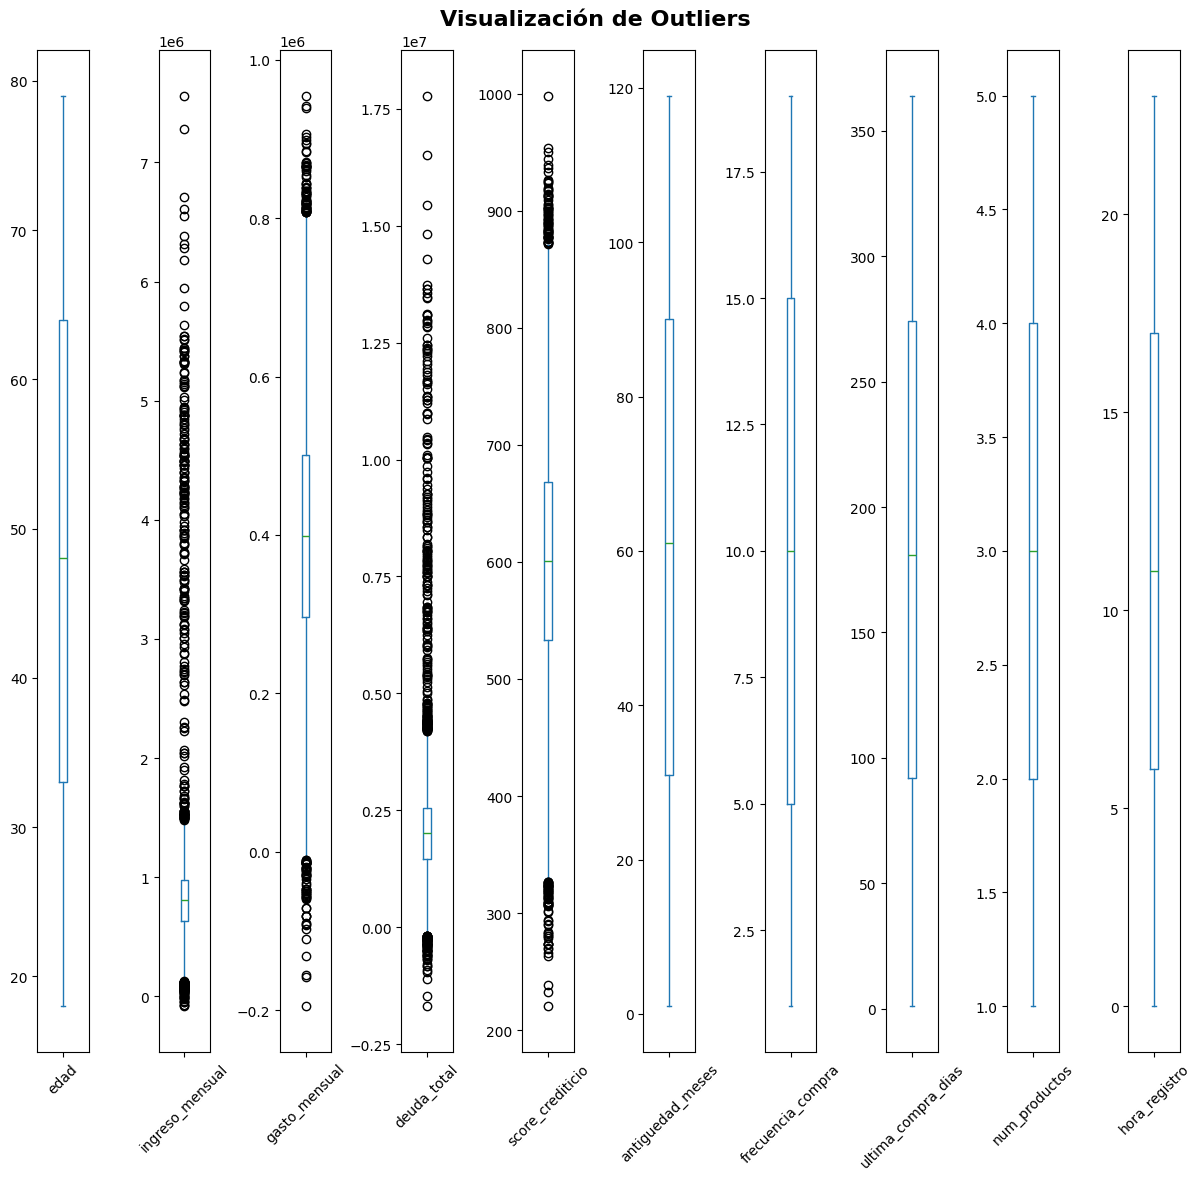

In [239]:
# Arrays de variables numéricas para análisis de atípicos
registro_atipicos=["edad",	"ingreso_mensual",	"gasto_mensual",	"deuda_total",	"score_crediticio",	"antiguedad_meses",	"frecuencia_compra",	"ultima_compra_dias",	"num_productos",	"hora_registro"]

# Gráfico BoxPlot
fig, axes = plt.subplots(1, 10, figsize=(20,20))
axes = axes.flatten()
for i, col in enumerate(registro_atipicos):
  data[col].plot(kind='box',figsize=(12,12), ax=axes[i])
  axes[i].tick_params(axis="x", labelrotation=45)

plt.suptitle("Visualización de Outliers", fontsize=16, fontweight="bold")
plt.tight_layout()

plt.show()

### Análisis de distribución inicial de columnas numéricas
* Se generan visualizaciones de cómo es la distribución inicial de principales variables numéricas que contienen datos sucios y serán sometidas a limpieza.

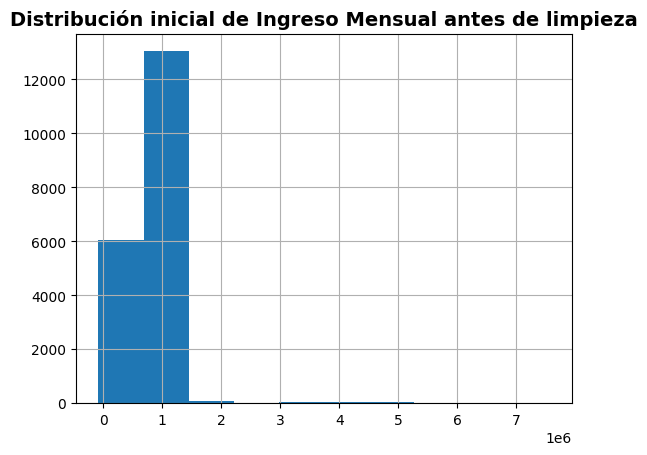

In [240]:
data['ingreso_mensual'].hist()
plt.title('Distribución inicial de Ingreso Mensual antes de limpieza', fontsize=14, fontweight="bold")
plt.show()

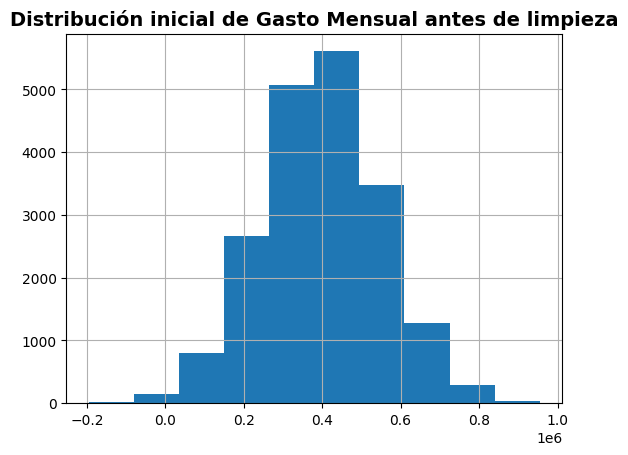

In [241]:
data['gasto_mensual'].hist()
plt.title('Distribución inicial de Gasto Mensual antes de limpieza', fontsize=14, fontweight="bold")
plt.show()

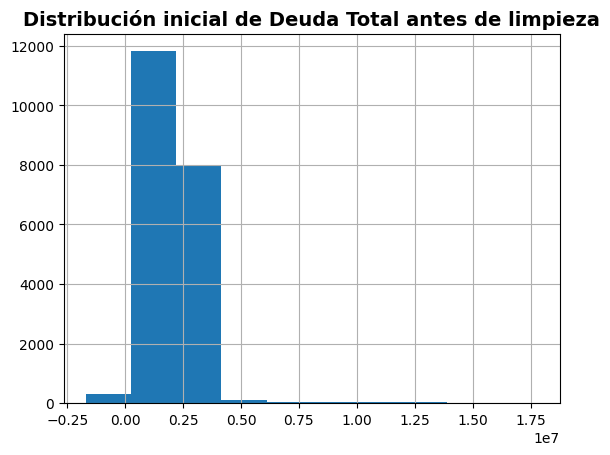

In [242]:
data['deuda_total'].hist()
plt.title('Distribución inicial de Deuda Total antes de limpieza', fontsize=14, fontweight="bold")
plt.show()

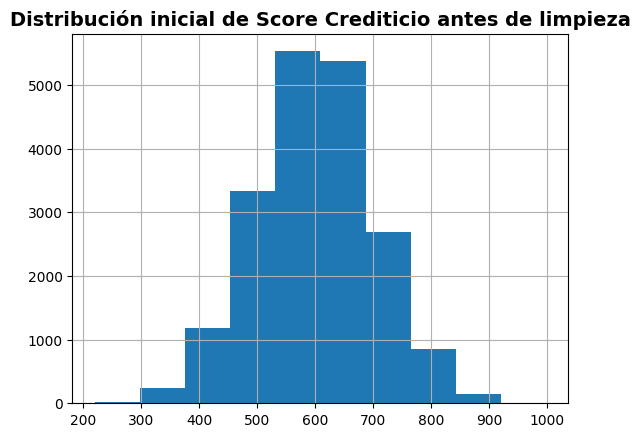

In [243]:
data['score_crediticio'].hist()
plt.title('Distribución inicial de Score Crediticio antes de limpieza', fontsize=14, fontweight="bold")
plt.show()

## 1.2 Limpieza y Transformación de Datos

### Detección de inconsistencias

In [244]:
# Deteccion de inconsistencias: negativos o ceros en columnas que deberian ser positivas
columnas_negativas_check = [
    "ingreso_mensual", "gasto_mensual", "deuda_total", "score_crediticio",
    "edad", "antiguedad_meses", "frecuencia_compra", "ultima_compra_dias",
    "num_productos", "hora_registro",
]
columnas_ceros_check = [
    "ingreso_mensual", "gasto_mensual", "deuda_total", "score_crediticio",
    "edad", "antiguedad_meses",
]

conteo_negativos = {}
conteo_ceros = {}
for col in columnas_negativas_check:
    if col in data.columns:
        conteo_negativos[col] = int((data[col] < 0).sum())
for col in columnas_ceros_check:
    if col in data.columns:
        conteo_ceros[col] = int((data[col] == 0).sum())

conteo_negativos = {k: v for k, v in conteo_negativos.items() if v > 0}
conteo_ceros = {k: v for k, v in conteo_ceros.items() if v > 0}

print("Negativos detectados:", conteo_negativos if conteo_negativos else "ninguno")
print("Ceros detectados:", conteo_ceros if conteo_ceros else "ninguno")

Negativos detectados: {'ingreso_mensual': 11, 'gasto_mensual': 68, 'deuda_total': 143}
Ceros detectados: ninguno


In [245]:
# Tratamiento: corrige valores negativos convirtiendolos a valor absoluto
columns_to_correct = [
    "ingreso_mensual", "gasto_mensual", "deuda_total", "score_crediticio",
    "edad", "antiguedad_meses", "frecuencia_compra", "ultima_compra_dias",
    "num_productos", "hora_registro",
]

for col in columns_to_correct:
    if col in data.columns:
        data[col] = data[col].abs()

print("Valores negativos corregidos a valores absolutos en las columnas relevantes.")

Valores negativos corregidos a valores absolutos en las columnas relevantes.


### Clases y Funciones necesarias

In [246]:
class CorrelationFilter(BaseEstimator, TransformerMixin):
  """
  Eliminación de variables correlacionadas

  Parámetros
  ----------
  BaseEstimator : Clase base para estimadores en scikit-learn.
  TransformerMixin : Clase base para transformadores en scikit-learn.

  Atributos
  ---------
  columns_to_drop_ : array-like
    Nombres de las columnas a eliminar.
  threshold : float
    Umbral de correlación.
  Returns
  -------
  DataFrame
    Conjunto de datos sin variables correlacionadas.
  """
  def __init__(self, threshold=0.9):
    self.threshold = threshold
    self.columns_to_drop_ = None

  def fit(self, X, y=None):
    X_df = pd.DataFrame(X)

    corr_matrix = X_df.corr().abs()
    upper = corr_matrix.where(
      np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
    )

    self.columns_to_drop_ = [
        col for col in upper.columns if any(upper[col] > self.threshold)
    ]

    return self

  def transform(self, X):
    X_df = pd.DataFrame(X)
    X_filtered = X_df.drop(columns=self.columns_to_drop_, errors="ignore")
    return X_filtered.values

In [247]:
def evaluar(modelo: BaseEstimator, X_train: np.array, X_test: np.array, y_train: np.array, y_test: np.array):
  """
  Retorna las métricas del modelo

  Parámetros
  ----------
  modelo : BaseEstimator
    Modelo a evaluar.
  X_train : np.array
    Conjunto de datos de entrenamiento.
  X_test : np.array
    Conjunto de datos de prueba.
  y_train : np.array
    Etiquetas de entrenamiento.
  y_test : np.array
    Etiquetas de prueba
  Returns
  -------
  dict
    Diccionario con las métricas del modelo.

  """
  modelo.fit(X_train, y_train)

  y_pred = modelo.predict(X_test)
  y_prob = modelo.predict_proba(X_test)[:,1]

  return {
    "accuracy": accuracy_score(y_test, y_pred),
    "f1": f1_score(y_test, y_pred),
    "roc_auc": roc_auc_score(y_test, y_prob)
  }

In [248]:
class FeatureEngineering(BaseEstimator, TransformerMixin):
  """
  Ingeniería de características

  Parámetros
  ----------
  BaseEstimator : Clase base para estimadores en scikit-learn.
  TransformerMixin : Clase base para transformadores en scikit-learn.

  Atributos
  ---------
  columns_ : array-like
    Nombres de las columnas a transformar.
  Returns
  -------
  DataFrame
    Conjunto de datos con nuevas características.
  """
  def __init__(self):
    pass

  def fit(self, X, y=None):
    return self

  def transform(self, X):
    X = X.copy()
    
    # razón de endeudamiento
    X["ratio_endeudamiento"] = X["deuda_total"] / X["ingreso_mensual"]

    # porcentaje de gasto respecto al ingreso
    X['porcentaje_gasto'] = X['gasto_mensual'] / X['ingreso_mensual']
    
    return X

In [249]:
class Winsorizer(BaseEstimator, TransformerMixin):
    def __init__(self, limits=(0.05, 0.05)):
        self.limits = limits

    def fit(self, X, y=None):
        X_df = pd.DataFrame(X)
        # Calculamos y guardamos los límites matemáticos AQUÍ (Fase de aprendizaje)
        self.lower_bounds_ = X_df.quantile(self.limits[0])
        self.upper_bounds_ = X_df.quantile(1 - self.limits[1])
        self.columns_ = X_df.columns if isinstance(X, pd.DataFrame) else np.arange(X.shape[1])
        return self

    def transform(self, X):
        X_df = pd.DataFrame(X, columns=self.columns_).copy()
        X_df = X_df.astype("float64")
        # Aplicamos los límites guardados
        for col in self.columns_:
            X_df[col] = np.clip(X_df[col], self.lower_bounds_[col], self.upper_bounds_[col])
        return X_df

    def get_feature_names_out(self, input_features=None):
        if input_features is None:
            return np.array(self.columns_)
        else:
            return np.array(input_features)

In [250]:
# Define función para eliminar duplicados

def tratar_duplicados(X : pd.DataFrame, drop = True):
  """
  Tratamiento de duplicados

  Parámetros
  ----------
  X : DataFrame
    Conjunto de datos.
  drop : bool
    Si se deben eliminar los duplicados.

  Retorna
  -------
  DataFrame
    Conjunto de datos sin duplicados.
  """
  return X.drop_duplicates() if drop else X

In [251]:
class DataFrameConverter(BaseEstimator, TransformerMixin):
  """
  Convierte un array en un DataFrame

  Parámetros
  ----------
  BaseEstimator : Clase base para estimadores en scikit-learn.
  TransformerMixin : Clase base para transformadores en scikit-learn.

  Atributos
  ---------
  feature_names_ : array-like
    Nombres de las columnas.
  Returns
  -------
  DataFrame
    Conjunto de datos con nombres de columnas.
  """
  def __init__(self, preprocessor):
    self.preprocessor = preprocessor
    self.feature_names_ = None

  def fit(self, X, y=None):
    # Obtener nombres después de fit del preprocessor
    self.feature_names_ = self.preprocessor.get_feature_names_out()
    return self

  def transform(self, X):
    return pd.DataFrame(X, columns=self.feature_names_)

### Construcción de arrays para procesamiento

In [252]:
numerical_features = ["ratio_endeudamiento", "porcentaje_gasto", "gasto_mensual", "score_crediticio", "ingreso_mensual", "deuda_total", "edad", "antiguedad_meses", "frecuencia_compra", "ultima_compra_dias", "num_productos", "hora_registro"] # Define listado de variables numéricas
categorical_nominales = ["tiene_tarjeta_credito", "genero", "region", "estado_civil", "canal_registro","dia_semana_registro"] # Define listado de variables categóricas nominales
categorical_ordinales = ["tipo_plan", "uso_app"] # Define listado de variables categóricas ordinales
date_time_features = ["fecha_registro"] # Define listado de variables de fecha y hora
orden_tipo_plan = ['Basico', 'Estandar', 'Premium'] # Define orden para variable ordinal tipo_plan
orden_uso_app = ['Bajo', 'Medio', 'Alto'] # Define orden para variable ordinal uso_app

### Pipelines para cada tipo de conjunto


In [253]:
# Define pipeline para variables numéricas
pipeline_numerical_features = Pipeline(steps=[
    ('winsorizer', Winsorizer(limits=(0.05, 0.05))), # Aplica Winsorización para limitar outliers al 5%
    ('imputer', SimpleImputer(strategy='mean')), # Imputa valores faltantes con el promedio
    ('scaler', StandardScaler()) # Escala características numéricas
])

In [254]:
# Define pipeline para variables categóricas nominales
pipeline_nominales = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')), # Imputa valores faltantes con la moda
    ('onehot', OneHotEncoder(handle_unknown='ignore')) # Aplica codificación OneHotEncoder para variables nominales
])

In [255]:
# Define pipeline para variables categóricas ordinales
pipeline_ordinales = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')), # Imputa valores faltantes con la moda
    ('ordinal', OrdinalEncoder(categories=[orden_tipo_plan, orden_uso_app])) # Aplica codificación OrdinalEncoder para variables ordinales con orden definido
])

### Integración de pipelines de transformación


In [256]:
# Combina pipelines para aplicar transformaciones específicas a cada tipo de variable
preprocesador = ColumnTransformer(
    transformers=[
        ('num_limpios', pipeline_numerical_features, numerical_features),
        ('cat_nom', pipeline_nominales, categorical_nominales),
        ('cat_ord', pipeline_ordinales, categorical_ordinales),
    ],
    remainder='drop' # Elimina columnas no especificadas
)

### Pipeline para limpieza


In [257]:
# Elimina duplicados y separa objetivo/features para mantener alineacion
data_sin_dup = tratar_duplicados(data, drop=True).reset_index(drop=True)
var_dep = data_sin_dup["abandono"].reset_index(drop=True)
var_indep = data_sin_dup.drop(columns=["abandono"])

In [258]:
# Define pipeline de limpieza que incluye eliminación de duplicados, ingeniería de características y preprocesamiento específico para cada tipo de variable
pipeline_limpieza = Pipeline(
    steps=[
        ("duplicados", FunctionTransformer(tratar_duplicados, kw_args={"drop": True})), # Elimina duplicados del dataset
        ("feature_engineering", FeatureEngineering()), # Agrega nuevas características
        ("preprocesamiento", preprocesador),
        ("conversion", DataFrameConverter(preprocesador)), # Convierte la salida a DataFrame con nombres
    ]
)

In [259]:
# Aplica pipeline de limpieza al dataset y obtiene el resultado transformado
data_transformada = pipeline_limpieza.fit_transform(var_indep)
data_transformada.columns = data_transformada.columns.str.replace("num_limpios__", "")
data_transformada.columns = data_transformada.columns.str.replace("cat_nom__", "")
data_transformada.columns = data_transformada.columns.str.replace("cat_ord__", "")
data_transformada["abandono"] = var_dep.to_numpy()
data_transformada.head()

,ratio_endeudamiento,porcentaje_gasto,gasto_mensual,score_crediticio,ingreso_mensual,deuda_total,edad,antiguedad_meses,frecuencia_compra,ultima_compra_dias,...,dia_semana_registro_Domingo,dia_semana_registro_Jueves,dia_semana_registro_Lunes,dia_semana_registro_Martes,dia_semana_registro_Miercoles,dia_semana_registro_Sabado,dia_semana_registro_Viernes,tipo_plan,uso_app,abandono
0,-0.087339,8.917517e-02,0.928655,-1.616594,5.299850e-01,0.572683,0.995847,1.213020,-0.724598,1.589155,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1
1,-1.135785,-1.246435e+00,-0.634528,-0.283686,1.882364e+00,-0.532574,0.141534,0.142729,-0.358339,1.202924,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,2.0,1.0,0
2,0.000000,4.360560e-16,-0.091194,1.852509,5.168572e-16,1.849046,-0.029329,-1.581629,0.374180,0.478739,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,2.0,2.0,0
3,2.483183,1.613845e+00,0.133315,-1.757904,-1.633970e+00,1.308836,0.312397,-1.581629,-1.273987,-0.168199,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,2.0,1
4,-0.398030,4.649992e-01,0.681864,-1.474195,-2.844893e-01,-0.509680,-0.997550,-1.373516,-0.907728,0.971185,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1


## 1.3 Resultados

In [260]:
# Muestra características del dataset después de la limpieza y transformación
data_transformada.info()

<class 'pandas.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 36 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   ratio_endeudamiento            20000 non-null  float64
 1   porcentaje_gasto               20000 non-null  float64
 2   gasto_mensual                  20000 non-null  float64
 3   score_crediticio               20000 non-null  float64
 4   ingreso_mensual                20000 non-null  float64
 5   deuda_total                    20000 non-null  float64
 6   edad                           20000 non-null  float64
 7   antiguedad_meses               20000 non-null  float64
 8   frecuencia_compra              20000 non-null  float64
 9   ultima_compra_dias             20000 non-null  float64
 10  num_productos                  20000 non-null  float64
 11  hora_registro                  20000 non-null  float64
 12  tiene_tarjeta_credito_0        20000 non-null  float64
 1

In [261]:
# Obtención de datos nulos después de la limpieza y transformación
data_transformada.isnull().sum()

ratio_endeudamiento              0
porcentaje_gasto                 0
gasto_mensual                    0
score_crediticio                 0
ingreso_mensual                  0
deuda_total                      0
edad                             0
antiguedad_meses                 0
frecuencia_compra                0
ultima_compra_dias               0
num_productos                    0
hora_registro                    0
tiene_tarjeta_credito_0          0
tiene_tarjeta_credito_1          0
genero_Femenino                  0
genero_Masculino                 0
genero_Otro                      0
region_Centro                    0
region_Norte                     0
region_Sur                       0
estado_civil_Casado              0
estado_civil_Divorciado          0
estado_civil_Soltero             0
canal_registro_App               0
canal_registro_Tienda            0
canal_registro_Web               0
dia_semana_registro_Domingo      0
dia_semana_registro_Jueves       0
dia_semana_registro_

In [262]:
# Obtención de duplicados después de la limpieza y transformación
data_transformada.duplicated().sum()

np.int64(0)

In [263]:
# Medidas estadísticas descriptivas después de la limpieza y transformación
data_transformada.describe()

,ratio_endeudamiento,porcentaje_gasto,gasto_mensual,score_crediticio,ingreso_mensual,deuda_total,edad,antiguedad_meses,frecuencia_compra,ultima_compra_dias,...,dia_semana_registro_Domingo,dia_semana_registro_Jueves,dia_semana_registro_Lunes,dia_semana_registro_Martes,dia_semana_registro_Miercoles,dia_semana_registro_Sabado,dia_semana_registro_Viernes,tipo_plan,uso_app,abandono
count,2.000000e+04,2.000000e+04,2.000000e+04,2.000000e+04,2.000000e+04,2.000000e+04,2.000000e+04,2.000000e+04,2.000000e+04,2.000000e+04,...,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000
mean,-2.547296e-16,2.877698e-16,-1.612044e-16,2.749800e-16,3.822720e-16,-8.668621e-17,5.391243e-17,5.826450e-17,6.998846e-17,5.684342e-18,...,0.142000,0.143350,0.143100,0.143350,0.146700,0.140150,0.141350,1.011050,0.995350,0.396750
std,1.000025e+00,1.000025e+00,1.000025e+00,1.000025e+00,1.000025e+00,1.000025e+00,1.000025e+00,1.000025e+00,1.000025e+00,1.000025e+00,...,0.349059,0.350438,0.350184,0.350438,0.353815,0.347151,0.348391,0.814408,0.818695,0.489236
min,-1.450871e+00,-1.494549e+00,-1.849579e+00,-1.874794e+00,-1.855212e+00,-1.780683e+00,-1.567093e+00,-1.581629e+00,-1.640247e+00,-1.577945e+00,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,-7.182025e-01,-7.052458e-01,-7.195415e-01,-7.042625e-01,-7.103991e-01,-7.432500e-01,-8.836419e-01,-8.681012e-01,-9.077280e-01,-8.730721e-01,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,-1.283715e-01,-6.711289e-02,0.000000e+00,0.000000e+00,5.168572e-16,-3.815063e-03,-2.932858e-02,2.380803e-02,7.920358e-03,-1.370640e-02,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,0.000000
75%,4.799811e-01,4.573826e-01,7.065596e-01,7.071144e-01,7.049931e-01,7.181346e-01,8.819390e-01,8.859869e-01,9.235687e-01,8.842825e-01,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.000000,2.000000,1.000000
max,2.483183e+00,2.489446e+00,1.855071e+00,1.852509e+00,1.882364e+00,1.849046e+00,1.565390e+00,1.569784e+00,1.656087e+00,1.589155e+00,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,2.000000,2.000000,1.000000


### Resultados de codificación ordinal

In [264]:
# Conteo de valores de variable Tipo Plan después de codificación ordinal y limpieza
data_transformada.tipo_plan.value_counts()

tipo_plan
2.0    6744
1.0    6733
0.0    6523
Name: count, dtype: int64

In [265]:
# Conteo de valores de variable Uso App después de codificación ordinal y limpieza
data_transformada.uso_app.value_counts()

uso_app
0.0    6749
2.0    6656
1.0    6595
Name: count, dtype: int64

### Análisis de distribución final

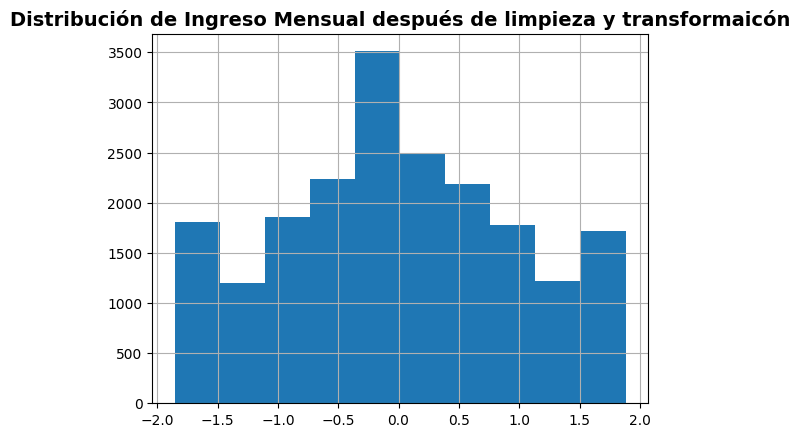

In [266]:
data_transformada['ingreso_mensual'].hist()
plt.title('Distribución de Ingreso Mensual después de limpieza y transformaicón', fontsize=14, fontweight="bold")
plt.show()

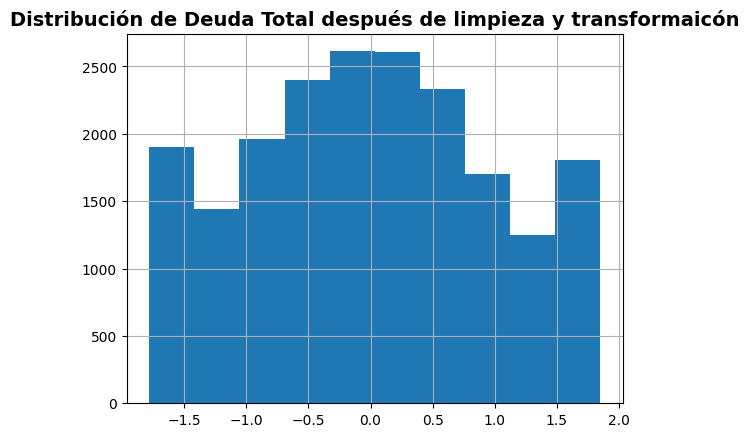

In [267]:
data_transformada['deuda_total'].hist()
plt.title('Distribución de Deuda Total después de limpieza y transformaicón', fontsize=14, fontweight="bold")
plt.show()

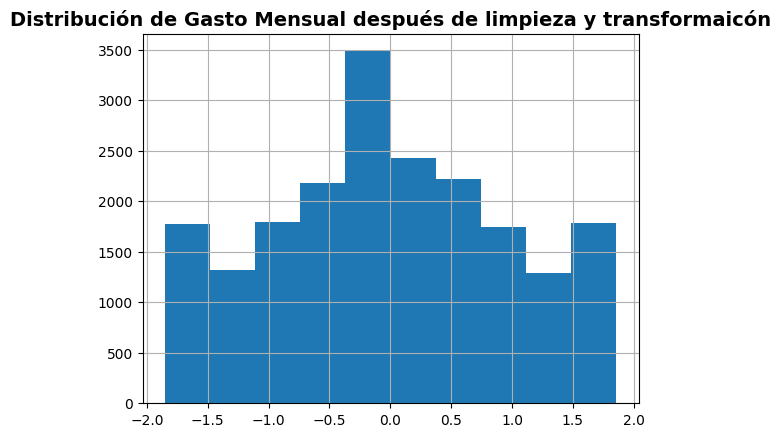

In [268]:
data_transformada['gasto_mensual'].hist()
plt.title('Distribución de Gasto Mensual después de limpieza y transformaicón', fontsize=14, fontweight="bold")
plt.show()

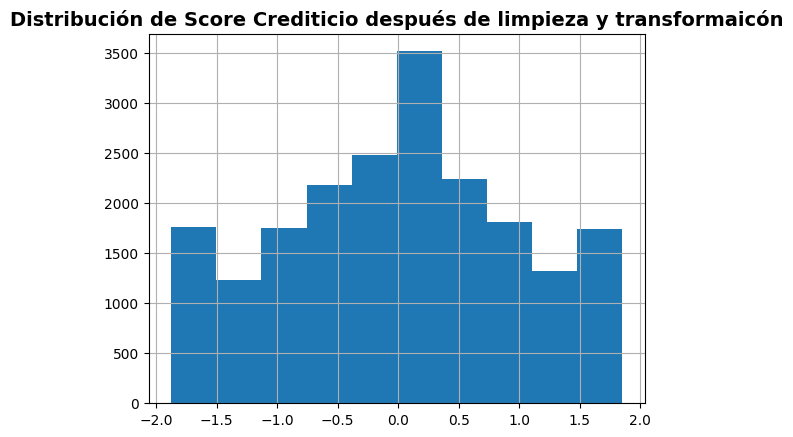

In [269]:
data_transformada['score_crediticio'].hist()
plt.title('Distribución de Score Crediticio después de limpieza y transformaicón', fontsize=14, fontweight="bold")
plt.show()

In [270]:
import os

# definir la ruta relativa: subir un nivel (..) y luego entrar en 'data'
target_dir = os.path.join('..', 'data')
file_name = 'dataset_clientes_limpio.csv'
full_path = os.path.join(target_dir, file_name)

# asegurar que la carpeta 'data' existe en el nivel superior
# os.makedirs creará la carpeta si no existe
if not os.path.exists(target_dir):
    os.makedirs(target_dir, exist_ok=True)
    print(f"Directorio creado o verificado en: {os.path.abspath(target_dir)}")

# guardar el DataFrame
data_transformada.to_csv(full_path, index=False, encoding='utf-8')

print(f"Archivo guardado exitosamente en: {full_path}")

Archivo guardado exitosamente en: ..\data\dataset_clientes_limpio.csv
